#  Dimension Reduction on Macroeconomic Data

Companion to the **Principal Components Analysis** and **K-Means Clustering** sections of the
lecture. The lecture's claim is that a large panel of macroeconomic indicators is really
measuring a small number of latent factors, so that instead of $X_t \in \mathbb{R}^M$ we can
work with $F_t \in \mathbb{R}^m$ where $m \ll M$.


*Literature.* Sargent and Sims (1977) show that a small number of dynamic factors explains a
large proportion of the variance in US macroeconomic indicators. Bai (2008) and Stock and Watson
(2006) survey what followed; McCracken and Ng (2016) assembled FRED-MD.

**After this notebook you should be able to:**

1. explain why transforming and standardizing are both required before PCA;
2. read a scree plot and defend a choice of $m$;
3. attach an economic interpretation to a component, handling its arbitrary sign;
4. cluster series with k-means and judge whether the clusters mean anything.

## 1. Data

FRED-MD is a monthly panel of US macroeconomic indicators, revised each month by the Federal
Reserve Bank of St. Louis.
Its first row holds a transformation code per series rather than data, and series start at
different dates, so the raw panel is unbalanced.

In [1]:
import ssl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# FRED serves the file over a TLS chain that some Python builds reject
ssl._create_default_https_context = ssl._create_stdlib_context

pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

SEED = 710
N_COMPONENTS = 20          # how many components to extract and inspect
VARIANCE_TARGET = 0.50     # share of panel variance we ask the factors to explain

FRED_MD = ("https://www.stlouisfed.org/-/media/project/frbstl/stlouisfed/research/"
           "fred-md/monthly/2025-07-md.csv?sc_lang=en&hash=A1E7A098FEFE58C453870371DB34E6AF")

BLUE, GREEN, GOLD, RED = "#003865", "#64A70B", "#F2A900", "#DA291C"

In [2]:
def load_fred_md(path):
    """Load FRED-MD. The first row holds transformation codes; the last three are footnotes."""
    print("Be patient: loading FRED-MD from the St. Louis Fed")
    raw = pd.read_csv(path)[:-3]

    codes = raw.iloc[0, 1:].astype(int)
    raw = raw.drop(index=0).set_index("sasdate")
    raw.index = pd.to_datetime(raw.index, format="%m/%d/%Y").to_period("M")
    raw.index.name = "month"

    print("Done")
    return raw.astype(float), codes


fred, transformation_codes = load_fred_md(FRED_MD)

print(f"\nPanel : {fred.shape[0]} months x {fred.shape[1]} series, "
      f"{fred.index.min()} to {fred.index.max()}")
print(f"Codes : {transformation_codes.value_counts().sort_index().to_dict()} "
      f"(code: number of series)")
fred.iloc[:3, :6]

Be patient: loading FRED-MD from the St. Louis Fed


Done

Panel : 795 months x 126 series, 1959-01 to 2025-03
Codes : {1: 11, 2: 19, 4: 10, 5: 52, 6: 33, 7: 1} (code: number of series)


,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO
month,,,,,,
1959-01,2583.560,2426.0,15.188,276676.8154,17689.2397,21.9616
1959-02,2593.596,2434.8,15.346,278713.9773,17819.0191,22.3917
1959-03,2610.396,2452.7,15.491,277775.2539,17967.9134,22.7142


### 1.1 Transform


McCracken and Ng (2016) supply the appropriate transformation for each series as a code from 1 to 7.


(PCA decomposes a covariance matrix, which is only meaningful if the series are stationary. The transformations (hopefully) provide this stationarity.)

In [ ]:
def transxf(x, tcode):
    """Transform a single series as specified by its FRED-MD transformation code (1-7).

    Leading positions lost to differencing come back as NaN.
    """
    n = x.size
    small = 1e-6                    # treated as "too close to zero to take logs"

    y = np.nan * np.ones(n)
    y1 = np.nan * np.ones(n)
    result = np.nan * np.ones(n)

    if tcode == 1:                  # no transformation: x(t)
        result = x

    elif tcode == 2:                # first difference
        y[1:] = x[1:] - x[:-1]
        result = y

    elif tcode == 3:                # second difference
        y[2:] = x[2:] - 2 * x[1:-1] + x[:-2]
        result = y

    elif tcode == 4:                # natural log
        if np.nanmin(x) >= small:
            result = np.log(x)

    elif tcode == 5:                # first difference of logs: growth rate
        if np.nanmin(x[pd.notnull(x)]) > small:
            log_x = np.log(x)
            y[1:] = log_x[1:] - log_x[:-1]
            result = y

    elif tcode == 6:                # second difference of logs
        if np.nanmin(x[pd.notnull(x)]) > small:
            log_x = np.log(x)
            y[2:] = log_x[2:] - 2 * log_x[1:-1] + log_x[:-2]
            result = y

    elif tcode == 7:                # first difference of the percent change
        y1[1:] = (x[1:] - x[:-1]) / x[:-1]
        y[2:] = y1[2:] - y1[1:-1]
        result = y

    return result


transformed = pd.DataFrame(
    {name: transxf(fred[name].to_numpy(), transformation_codes[name]) for name in fred.columns},
    index=fred.index,
)
transformed.iloc[:3, :6]

,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO
month,,,,,,
1959-01,NaN,NaN,NaN,NaN,NaN,NaN
1959-02,0.0039,0.0036,0.0103,0.0073,0.0073,0.0194
1959-03,0.0065,0.0073,0.0094,-0.0034,0.0083,0.0143


### 1.2 Balance and standardize

There should be no missing data in the dataframe. So we first drop rows with missing data.

Standardizing is the second requirement. FRED-MD mixes interest rates in percentage points, employment in thousands of persons and growth rates in decimals.
Since PCA maximizes explained variance, without standardization the components would rank series by the size of their units.
Putting every series on mean zero and unit variance means PCA decomposes the **correlation** matrix.

In [4]:
missing_counts = transformed.isna().sum().sort_values(ascending=False)
balanced = transformed.dropna()

print(f"Unbalanced : {len(transformed)} months ({transformed.index.min()} to "
      f"{transformed.index.max()})")
print(f"Balanced   : {len(balanced)} months ({balanced.index.min()} to "
      f"{balanced.index.max()}), {len(transformed) - len(balanced)} dropped\n")
print("The series that cost the most months:")
print(missing_counts.head(4).to_string())
print(f"\nWithout {missing_counts.index[0]}, the panel would start in "
      f"{transformed.drop(columns=missing_counts.index[0]).dropna().index.min()}")

spread = balanced.std().sort_values(ascending=False)
standardized = pd.DataFrame(StandardScaler().fit_transform(balanced),
                            columns=balanced.columns, index=balanced.index)

print(f"\nLargest / smallest standard deviation before standardizing: "
      f"{spread.index[0]} {spread.iloc[0]:.2f} vs {spread.index[-1]} {spread.iloc[-1]:.4f} "
      f"({spread.iloc[0] / spread.iloc[-1]:,.0f}x)")
print(f"After standardizing: every series has unit variance")

Unbalanced : 795 months (1959-01 to 2025-03)
Balanced   : 395 months (1992-03 to 2025-03), 400 dropped

The series that cost the most months:
ACOGNO           398
UMCSENTx         229
TWEXAFEGSMTHx    169
ANDENOx          110

Without ACOGNO, the panel would start in 1978-02

Largest / smallest standard deviation before standardizing: HWI 261.75 vs CUSR0000SAS 0.0014 (189,853x)
After standardizing: every series has unit variance


## 2. Principal Components

`whiten=False` means the output components are not (re)scaled to have unit variance. This preserves the original relative magnitude of variance across components.

20 components from 126 series over 395 months

PC1 alone             : 15.8%
First 3 components    : 32.5%
First 8 components    : 52.2%  <- the 50% target
All 20 components     : 72.9%, leaving 27.1% unexplained


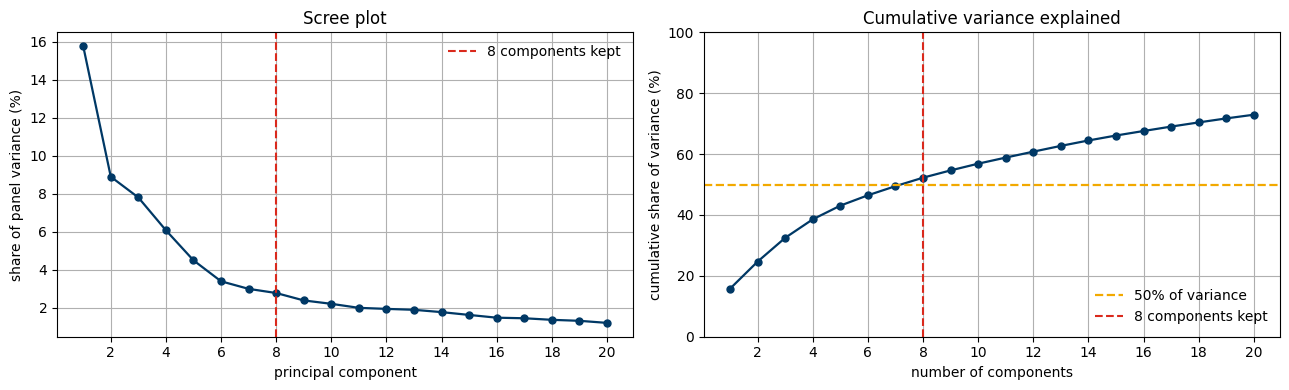

In [5]:
pca = PCA(n_components=N_COMPONENTS, whiten=False, svd_solver="full", random_state=SEED)
pca.fit(standardized)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_selected = int(np.argmax(cumulative >= VARIANCE_TARGET)) + 1
components = [f"PC{i + 1}" for i in range(N_COMPONENTS)]

print(f"{N_COMPONENTS} components from {standardized.shape[1]} series over "
      f"{len(standardized)} months\n")
print(f"{'PC1 alone':<22}: {explained[0]:.1%}")
print(f"{'First 3 components':<22}: {cumulative[2]:.1%}")
print(f"{f'First {n_selected} components':<22}: {cumulative[n_selected - 1]:.1%}  "
      f"<- the {100 * VARIANCE_TARGET:.0f}% target")
print(f"{f'All {N_COMPONENTS} components':<22}: {cumulative[-1]:.1%}, leaving "
      f"{1 - cumulative[-1]:.1%} unexplained")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, N_COMPONENTS + 1), 100 * explained, marker="o", ms=5, lw=1.6, color=BLUE)
axes[0].axvline(n_selected, color=RED, lw=1.5, ls="--", label=f"{n_selected} components kept")
axes[0].set_xlabel("principal component")
axes[0].set_ylabel("share of panel variance (%)")
axes[0].set_title("Scree plot")
axes[0].set_xticks(range(2, N_COMPONENTS + 1, 2))
axes[0].legend(frameon=False)

axes[1].plot(range(1, N_COMPONENTS + 1), 100 * cumulative, marker="o", ms=5, lw=1.6, color=BLUE)
axes[1].axhline(100 * VARIANCE_TARGET, color=GOLD, lw=1.6, ls="--",
                label=f"{100 * VARIANCE_TARGET:.0f}% of variance")
axes[1].axvline(n_selected, color=RED, lw=1.5, ls="--", label=f"{n_selected} components kept")
axes[1].set_xlabel("number of components")
axes[1].set_ylabel("cumulative share of variance (%)")
axes[1].set_title("Cumulative variance explained")
axes[1].set_xticks(range(2, N_COMPONENTS + 1, 2))
axes[1].set_ylim(0, 100)
axes[1].legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

The scree plot shows the amount of variance associated with each factor or principal component.

### 2.1 Interpreting the factors

**The sign of a component is arbitrary.** If $\widehat\lambda_k$ maximizes
$\lambda^\top X^\top X \lambda$ then so does $-\widehat\lambda_k$.

Each component below is oriented so that its
largest loading is positive, which makes the plot readable.

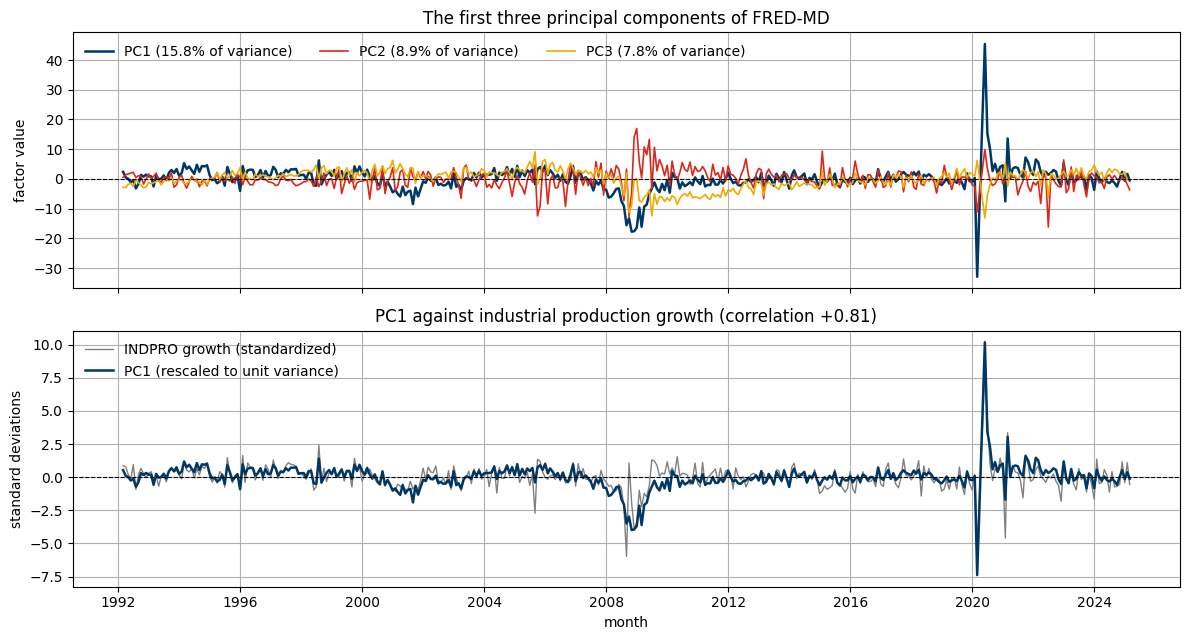

In [6]:
loadings = pd.DataFrame(pca.components_.T, index=standardized.columns, columns=components)
scores = pd.DataFrame(pca.transform(standardized), index=standardized.index, columns=components)

# Fix the arbitrary sign: orient each component so its dominant loading is positive
signs = np.sign(loadings.apply(lambda column: column[column.abs().idxmax()]))
loadings, scores = loadings * signs, scores * signs

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
month_index = scores.index.to_timestamp()

for name, colour, width in [("PC1", BLUE, 1.8), ("PC2", RED, 1.2), ("PC3", GOLD, 1.2)]:
    axes[0].plot(month_index, scores[name], color=colour, lw=width,
                 label=f"{name} ({explained[components.index(name)]:.1%} of variance)")
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_ylabel("factor value")
axes[0].set_title("The first three principal components of FRED-MD")
axes[0].legend(frameon=False, ncol=3)

axes[1].plot(month_index, standardized["INDPRO"], color="grey", lw=1.0,
             label="INDPRO growth (standardized)")
axes[1].plot(month_index, scores["PC1"] / scores["PC1"].std(), color=BLUE, lw=1.8,
             label="PC1 (rescaled to unit variance)")
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].set_ylabel("standard deviations")
axes[1].set_xlabel("month")
axes[1].set_title(f"PC1 against industrial production growth "
                  f"(correlation {scores['PC1'].corr(standardized['INDPRO']):+.2f})")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

In [7]:
for name in components[:3]:
    strongest = loadings[name].abs().nlargest(6).index
    print(f"{name} --- {explained[components.index(name)]:.1%} of panel variance")
    print(loadings.loc[strongest, name].round(3).to_string())
    print()

headline = {"INDPRO": "industrial production", "PAYEMS": "payroll growth",
            "UNRATE": "unemployment change", "CPIAUCSL": "CPI inflation",
            "FEDFUNDS": "fed funds change", "S&P 500": "S&P 500 return"}

print("Correlation of each factor with headline series")
pd.DataFrame({label: [scores[name].corr(standardized[series]) for name in components[:5]]
              for series, label in headline.items()}, index=components[:5]).round(2)

PC1 --- 15.8% of panel variance
PAYEMS       0.194
IPMANSICS    0.190
IPFPNSS      0.186
SRVPRD       0.185
INDPRO       0.182
CUMFNS       0.179

PC2 --- 8.9% of panel variance
CPIAUCSL         0.248
CUSR0000SA0L5    0.247
CPIULFSL         0.247
CUSR0000SA0L2    0.247
CPITRNSL         0.240
CUSR0000SAC      0.239

PC3 --- 7.8% of panel variance
PERMIT     0.249
PERMITW    0.245
HOUST      0.244
HOUSTW     0.243
PERMITS    0.242
HOUSTS     0.241

Correlation of each factor with headline series


,industrial production,payroll growth,unemployment change,CPI inflation,fed funds change,S&P 500 return
PC1,0.81,0.86,-0.65,0.13,0.40,0.35
PC2,-0.03,-0.05,0.02,0.83,-0.05,0.29
PC3,-0.28,-0.06,0.13,0.37,0.04,0.05
PC4,-0.20,-0.07,0.07,0.19,0.53,-0.01
PC5,-0.11,0.19,-0.16,0.09,-0.00,-0.01


The loadings and correlations agree, and the factors are nameable.

- **PC1 is a real-activity factor**: payroll employment, manufacturing and final-products
  industrial production, service-producing employment and capacity utilization, all entering
  with nearly identical weights and the same sign. It correlates $+0.86$ with payroll growth and
  $-0.65$ with the change in unemployment. These are not six independent pieces of information,
  they are six views of one thing --- and PC1 was never told about any of them.
- **PC2 is a price factor**: CPI aggregates dominate, it correlates $+0.83$ with inflation and
  is essentially uncorrelated with real activity.
- **PC3 is a housing factor**: building permits and housing starts take all six largest
  loadings.

---

## 3. K-Means Clustering

Where PCA compresses a panel into continuous factors, k-means assigns each object to exactly one
of $K$ groups by minimizing within-cluster variance.

Fitting matrix: 126 series x 395 months
WCSS falls from 46,930 at K = 1 to 26,519 at K = 12, a 43% reduction with no clear kink


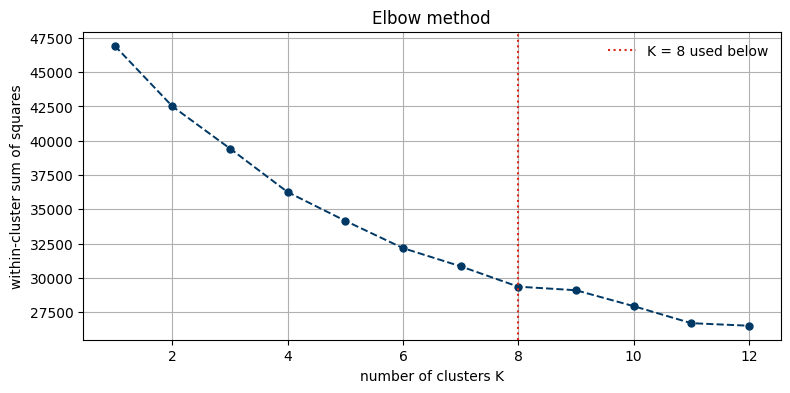

In [8]:
from sklearn.cluster import KMeans

K_CLUSTERS = 8             # the number of clusters taken forward below
K_RANGE = range(1, 13)

series_profiles = standardized.T          # series become the objects, months the features

wcss = [KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(series_profiles).inertia_
        for k in K_RANGE]

print(f"Fitting matrix: {series_profiles.shape[0]} series x {series_profiles.shape[1]} months")
print(f"WCSS falls from {wcss[0]:,.0f} at K = {K_RANGE[0]} to {wcss[-1]:,.0f} at "
      f"K = {K_RANGE[-1]}, a {1 - wcss[-1] / wcss[0]:.0%} reduction with no clear kink")

plt.plot(list(K_RANGE), wcss, marker="o", ms=5, ls="--", lw=1.4, color=BLUE)
plt.axvline(K_CLUSTERS, color=RED, lw=1.5, ls=":", label=f"K = {K_CLUSTERS} used below")
plt.xlabel("number of clusters K")
plt.ylabel("within-cluster sum of squares")
plt.title("Elbow method")
plt.legend(frameon=False)
plt.show()

McCracken and Ng place every series in one of eight groups, so
we set $K = 8$ and ask whether k-means, told nothing but the numbers, rediscovers them.

Agreement with the published groups (adjusted Rand index): 0.31

cluster 0:  29 series,  34% of them from 7 Prices
cluster 1:  28 series,  54% of them from 1 Output and income
cluster 2:  13 series, 100% of them from 7 Prices
cluster 3:  10 series, 100% of them from 3 Housing
cluster 4:  11 series, 100% of them from 6 Interest and exchange rates
cluster 5:   4 series, 100% of them from 6 Interest and exchange rates
cluster 6:  21 series,  38% of them from 5 Money and credit
cluster 7:  10 series,  90% of them from 2 Labor market


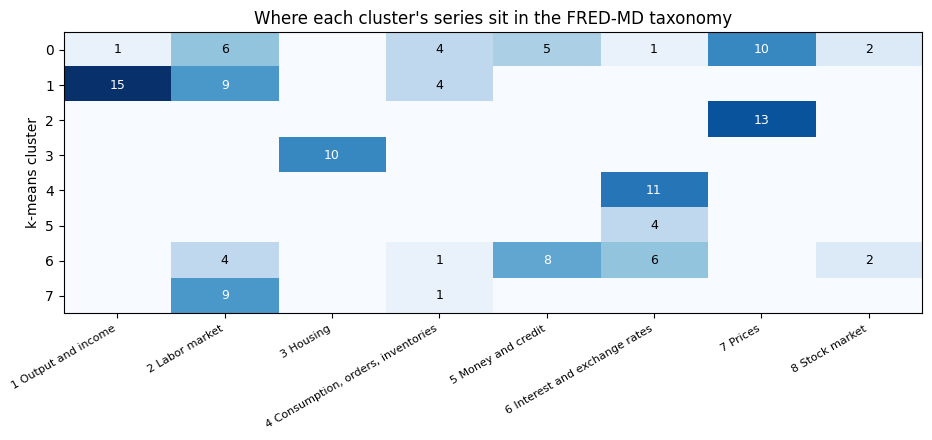

In [9]:
from sklearn.metrics import adjusted_rand_score

# The eight groups of the FRED-MD appendix (McCracken and Ng 2016)
FREDMD_GROUPS = {
    "1 Output and income": [
        "RPI", "W875RX1", "INDPRO", "IPFPNSS", "IPFINAL", "IPCONGD", "IPDCONGD", "IPNCONGD",
        "IPBUSEQ", "IPMAT", "IPDMAT", "IPNMAT", "IPMANSICS", "IPB51222S", "IPFUELS", "CUMFNS"],
    "2 Labor market": [
        "HWI", "HWIURATIO", "CLF16OV", "CE16OV", "UNRATE", "UEMPMEAN", "UEMPLT5", "UEMP5TO14",
        "UEMP15OV", "UEMP15T26", "UEMP27OV", "CLAIMSx", "PAYEMS", "USGOOD", "CES1021000001",
        "USCONS", "MANEMP", "DMANEMP", "NDMANEMP", "SRVPRD", "USTPU", "USWTRADE", "USTRADE",
        "USFIRE", "USGOVT", "CES0600000007", "AWOTMAN", "AWHMAN"],
    "3 Housing": [
        "HOUST", "HOUSTNE", "HOUSTMW", "HOUSTS", "HOUSTW", "PERMIT", "PERMITNE", "PERMITMW",
        "PERMITS", "PERMITW"],
    "4 Consumption, orders, inventories": [
        "DPCERA3M086SBEA", "CMRMTSPLx", "RETAILx", "ACOGNO", "AMDMNOx", "ANDENOx", "AMDMUOx",
        "BUSINVx", "ISRATIOx", "UMCSENTx"],
    "5 Money and credit": [
        "M1SL", "M2SL", "M2REAL", "BOGMBASE", "TOTRESNS", "NONBORRES", "BUSLOANS", "REALLN",
        "NONREVSL", "CONSPI", "DTCOLNVHFNM", "DTCTHFNM", "INVEST"],
    "6 Interest and exchange rates": [
        "FEDFUNDS", "CP3Mx", "TB3MS", "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA", "COMPAPFFx",
        "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM",
        "TWEXAFEGSMTHx", "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx"],
    "7 Prices": [
        "WPSFD49207", "WPSFD49502", "WPSID61", "WPSID62", "OILPRICEx", "PPICMM", "CPIAUCSL",
        "CPIAPPSL", "CPITRNSL", "CPIMEDSL", "CUSR0000SAC", "CUSR0000SAD", "CUSR0000SAS",
        "CPIULFSL", "CUSR0000SA0L2", "CUSR0000SA0L5", "PCEPI", "DDURRG3M086SBEA",
        "DNDGRG3M086SBEA", "DSERRG3M086SBEA", "CES0600000008", "CES2000000008", "CES3000000008"],
    "8 Stock market": ["S&P 500", "S&P div yield", "S&P PE ratio", "VIXCLSx"],
}

published = pd.Series({series: group for group, names in FREDMD_GROUPS.items() for series in names},
                      name="published group").loc[standardized.columns]
series_clusters = pd.Series(
    KMeans(n_clusters=K_CLUSTERS, n_init=10, random_state=SEED).fit_predict(series_profiles),
    index=standardized.columns, name="cluster",
)
overlap = pd.crosstab(series_clusters, published)

print(f"Agreement with the published groups (adjusted Rand index): "
      f"{adjusted_rand_score(published, series_clusters):.2f}\n")
for cluster, row in overlap.iterrows():
    print(f"cluster {cluster}: {row.sum():>3} series, {row.max() / row.sum():>4.0%} of them from "
          f"{row.idxmax()}")

fig, ax = plt.subplots(figsize=(9.5, 4.5))

ax.imshow(overlap, cmap="Blues", aspect="auto")
for i, cluster in enumerate(overlap.index):
    for j, group in enumerate(overlap.columns):
        count = overlap.loc[cluster, group]
        if count:
            ax.text(j, i, count, ha="center", va="center", fontsize=9,
                    color="white" if count > overlap.to_numpy().max() / 2 else "black")

ax.set_xticks(range(overlap.shape[1]))
ax.set_xticklabels(overlap.columns, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(overlap.shape[0]))
ax.set_ylabel("k-means cluster")
ax.set_title("Where each cluster's series sit in the FRED-MD taxonomy")
ax.grid(False)

plt.tight_layout()
plt.show()

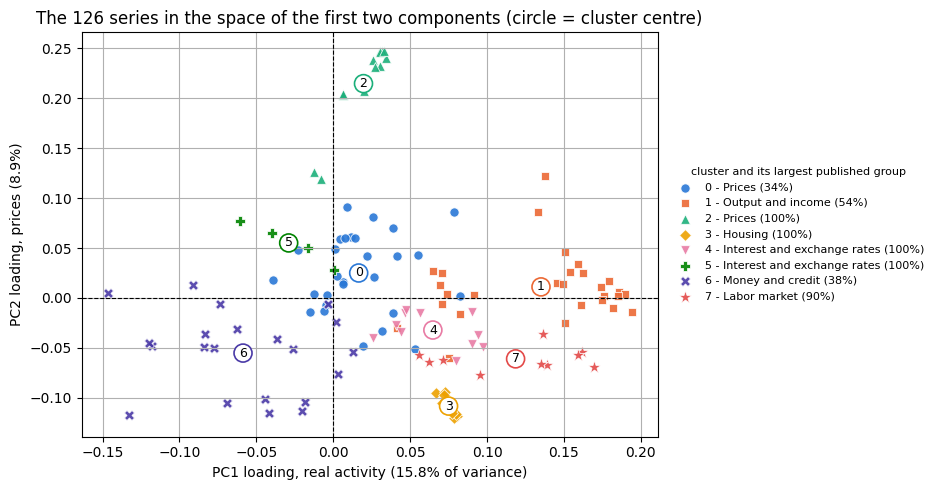

In [10]:
# Categorical hues in a fixed order, each paired with its own marker so the clusters stay
# separable in greyscale, in print, and with colour-vision deficiency
CLUSTER_COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                   "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
CLUSTER_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]
CLUSTER_SIZES = [44, 40, 48, 36, 48, 58, 52, 95]

cluster_centroids = loadings.groupby(series_clusters).mean()

fig, ax = plt.subplots(figsize=(9.5, 5))

for cluster, row in overlap.iterrows():
    members = series_clusters[series_clusters == cluster].index
    ax.scatter(loadings.loc[members, "PC1"], loadings.loc[members, "PC2"],
               s=CLUSTER_SIZES[cluster], color=CLUSTER_COLOURS[cluster],
               marker=CLUSTER_MARKERS[cluster], edgecolor="white", lw=0.6, alpha=0.9,
               label=f"{cluster} - {row.idxmax()[2:]} ({row.max() / row.sum():.0%})")
    ax.annotate(str(cluster), cluster_centroids.loc[cluster, ["PC1", "PC2"]], fontsize=9,
                ha="center", va="center", zorder=4,
                bbox=dict(boxstyle="circle,pad=0.2", fc="white",
                          ec=CLUSTER_COLOURS[cluster], lw=1.2))

ax.axhline(0, color="black", lw=0.8, ls="--")
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel(f"PC1 loading, real activity ({explained[0]:.1%} of variance)")
ax.set_ylabel(f"PC2 loading, prices ({explained[1]:.1%})")
ax.set_title("The 126 series in the space of the first two components (circle = cluster centre)")
ax.legend(frameon=False, fontsize=8, title="cluster and its largest published group",
          title_fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))

plt.tight_layout()
plt.show()

**Three clusters are published groups, exactly.** Cluster 3 is housing: all ten starts and permits
series, and nothing else. Cluster 2 is thirteen headline price indices, cluster 4 is eleven short
rates and Treasury yields. k-means was given no names and no group codes, only 395 numbers per
series.





**Extension questions**

1. **Interpretability: sparse PCA.** Every loading in PC1 is non-zero, so naming the factor
   meant eyeballing the largest six. Fit `sklearn.decomposition.SparsePCA` and compare. Does a
   factor with mostly-zero loadings tell a cleaner story, and what does it cost in explained
   variance?
2. **Look-ahead bias.** Standardize and fit the PCA on 1992--2010 only, then project 2011--2025
   onto those fixed loadings. How different are the factors?
3. **Cluster the months instead.** Fit k-means to `standardized` rather than its transpose, so
   each month is an object described by 126 series. What would this do?